In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
# files, channel = ["data/WA0089/LED_sweep/260625/850V_525MHz/led_100-10.h5"], "Channel 2"
# files, channel = ["data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-1.h5"], "Channel 1"


data_dir = Path("data/LED_Trigger/260629")
trig_file, trig_channel = ["data/LED_Trigger/260629/tri_seg_ch3_Pmt_trigger.h5"], "Channel 3"
files, channel = [ "data/LED_Trigger/260629/tri_seg_ch4_Pmt.h5"], "Channel 4"


# Configuration

In [3]:
chunk_size = 512 
baseline_window_width_ns = 20
basic_plots=True
time_origin="zero" # "orginal" or "zero"
# time_origin="orginal" # "orginal" or "zero"


In [4]:
if time_origin=='zero':
    baseline_window_ns = (0, baseline_window_width_ns)
else:
    max_sample_events = 2
    sample = read_waveform_sample(files, max_events=max_sample_events, channel=channel, time_origin=time_origin )
    time_ns = sample["time_ns"]
    adc_step_mV = sample["adc_step_mV"]
    print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
    print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
    print(f"ADC step: {adc_step_mV:.6f} mV\n")

    baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

# 2. Full Sample


In [5]:
prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    subtract_baseline=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None, 
    high_limit_mV=None, 
    margin_mV=0.0,
    max_saturated_samples=0,
    channel=channel,
    time_origin=time_origin, # "orginal" or "zero"
)

time_ns = prerocessed_data["time_ns"]
voltage_mV = prerocessed_data["voltage_mV"]

print(f"Preprocessed sample: {prerocessed_data["voltage_mV"].shape}")
print(f"Efficiency of saturation cut: {prerocessed_data['saturation_summary']['efficiency']*100:.3f} %")
print(f"N raw events: {prerocessed_data['saturation_summary']['n_total']}")

remove = ['is_saturated', 'n_saturated_samples']
preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in remove}
preprocessed_event_info.update({ 
    'event_file': prerocessed_data['event_file'],
    'event_segment': prerocessed_data['event_segment']
})

print(prerocessed_data.keys())
print()
print(f"prerocessed_data['event_info']: {prerocessed_data['event_info'].keys()}")


Preprocessed sample: (31673, 6401)
Efficiency of saturation cut: 99.972 %
N raw events: 31682
dict_keys(['time_ns', 'voltage_mV', 'event_file', 'event_segment', 'event_info', 'saturation_summary'])

prerocessed_data['event_info']: dict_keys(['is_saturated', 'n_saturated_samples', 'baseline_mean_mV', 'baseline_rms_mV', 'baseline_slope_mV_per_ns'])


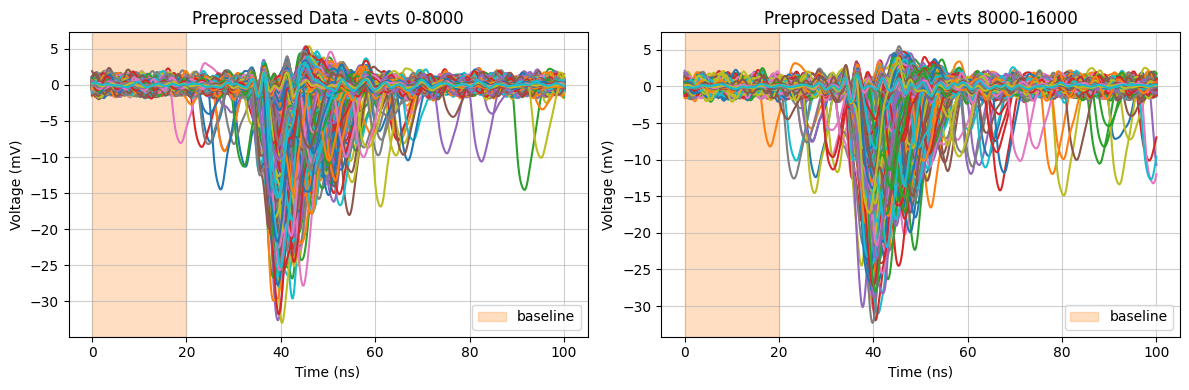

In [6]:
if basic_plots:
    n_to_plot = 8000
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    add_plot_waveforms(axes[0], time_ns, voltage_mV[:n_to_plot], title=f"Preprocessed Data - evts 0-{n_to_plot}")
    axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[0].legend(loc="lower right")

    add_plot_waveforms(axes[1], time_ns, voltage_mV[n_to_plot:2*n_to_plot], title=f"Preprocessed Data - evts {n_to_plot}-{2*n_to_plot}")
    axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[1].legend(loc="lower right")

    fig.tight_layout()

In [7]:
df = build_waveform_feature_dataframe(
    time_ns,
    voltage_mV,
    peak_threshold_mV=None,
    second_peak_min_height_frac=0.2,
    pre_peak_ns = 20,
    post_peak_ns = 80,
    pre_rise_ns = 10, 
    post_rise_ns = 80, 
    extra=preprocessed_event_info # extra dictionary to be added to the dataframe
)




/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


# Basic Selection

In [8]:

cutflow = CutFlow(len(df))

peaks_in_basleinewindow = reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 )
cutflow.apply( "peaks in the baseline", reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 ) )
# cutflow.apply( "SNR > 5", df["snr"] > 5 )
# cutflow.apply( "Single peak", df["n_peaks"] == 1 )
cutflow.print()

df_sel = df[cutflow.mask].copy()
waveforms_sel = voltage_mV[cutflow.mask]


df_sel.shape


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31673      100.0%        100.0%
peaks in the baseline         31610       99.8%         99.8%


(31610, 33)

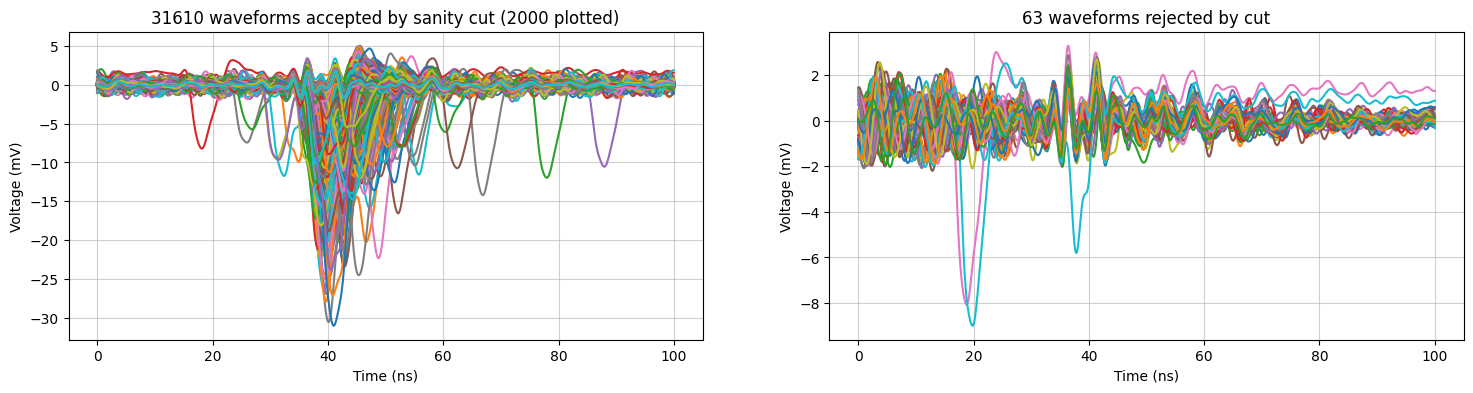

In [9]:
if basic_plots:
    evts_plot = (8000, 10000)
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    axes = axes.ravel()
    rejected_waveforms = voltage_mV[~peaks_in_basleinewindow.values]
    add_plot_waveforms(axes[0], time_ns, waveforms_sel[evts_plot[0]:evts_plot[1]], title=f"{len(waveforms_sel)} waveforms accepted by sanity cut ({evts_plot[1]-evts_plot[0]} plotted)")
    add_plot_waveforms(axes[1], time_ns, rejected_waveforms, title=f"{len(rejected_waveforms)} waveforms rejected by cut")


# Study Peak Timing

In [10]:
# late/early definitions

# data/WA0089/LED_sweep/260625/850V_525MHz/led_100-10.h5
# early_peak = (45.2, 45.9)
# late_peak  = (53.5, 54.1)
# time_peak_range = (40, 60)

# data/LED_Trigger/260629/tri_seg_ch4_Pmt.h5
early_peak = (35.0, 35.7)
late_peak  = (42.2, 43.3)
time_peak_range = (30, 60)

In [11]:
early_mask = df_sel["peak_time_ns"].between(early_peak[0], early_peak[1])
late_mask = df_sel["peak_time_ns"].between(late_peak[0], late_peak[1])

df_early = df_sel.loc[early_mask, :].copy()
df_late = df_sel.loc[late_mask, :].copy()


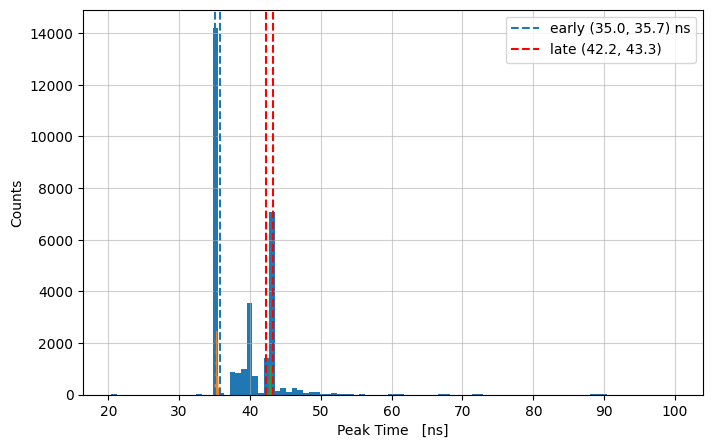

In [12]:
rg = None #time_peak_range
plt.hist(df_sel["peak_time_ns"], bins=100, range=rg);
plt.hist(df_early["peak_time_ns"], bins=100, range=rg, histtype='step');
plt.hist(df_late["peak_time_ns"], bins=100, range=rg, histtype='step');
plt.axvline(x = early_peak[0], linestyle='dashed', label=f'early {early_peak} ns')
plt.axvline(x = early_peak[1], linestyle='dashed')
plt.axvline(x = late_peak[0], linestyle='dashed', color='red', label=f'late {late_peak}')
plt.axvline(x = late_peak[1], linestyle='dashed', color='red');
plt.legend(loc='upper right')
plt.xlabel("Peak Time   [ns]")
plt.ylabel("Counts");

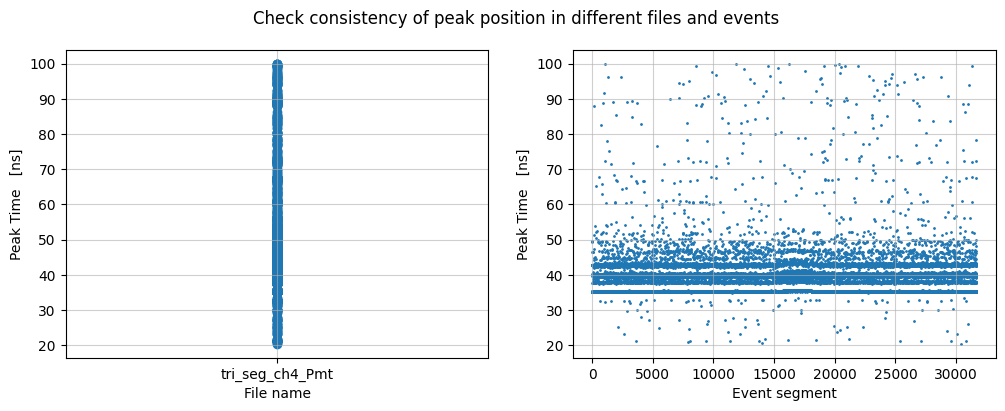

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
fig.suptitle('Check consistency of peak position in different files and events')
axes = axes.ravel()

df_sel["file"] = (df_sel["event_file"].str.rsplit("/", n=1).str[-1].str.removesuffix(".h5"))
axes[0].scatter( df_sel["file"], df_sel["peak_time_ns"] );
axes[0].set_xlabel('File name');
axes[0].set_ylabel("Peak Time   [ns]");

df_sel.groupby("event_file")["peak_time_ns"].value_counts()
axes[1].scatter(
    df_sel["event_segment"],
    df_sel["peak_time_ns"],
    s=1,
)
axes[1].set_xlabel('Event segment');
axes[1].set_ylabel("Peak Time   [ns]");

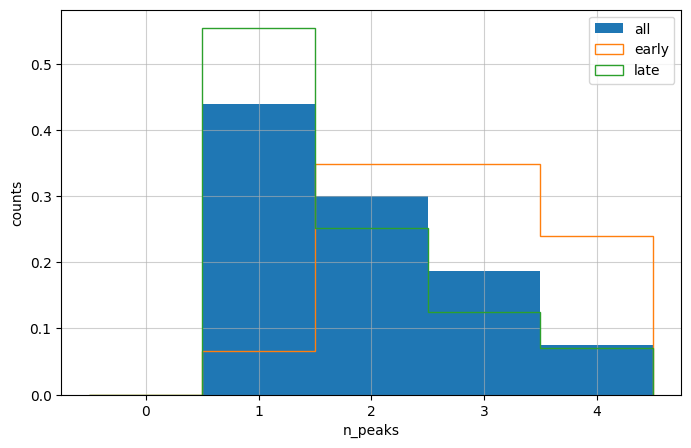

In [14]:

den=True
plt.hist(df_sel["n_peaks"], bins=np.arange(6)-0.5,density=den, label='all');
plt.hist(df_early["n_peaks"], bins=np.arange(6)-0.5, histtype='step',density=den, label='early');
plt.hist(df_late["n_peaks"], bins=np.arange(6)-0.5, histtype='step',density=den, label='late');
plt.xlabel('n_peaks')
plt.ylabel('counts')
plt.legend();

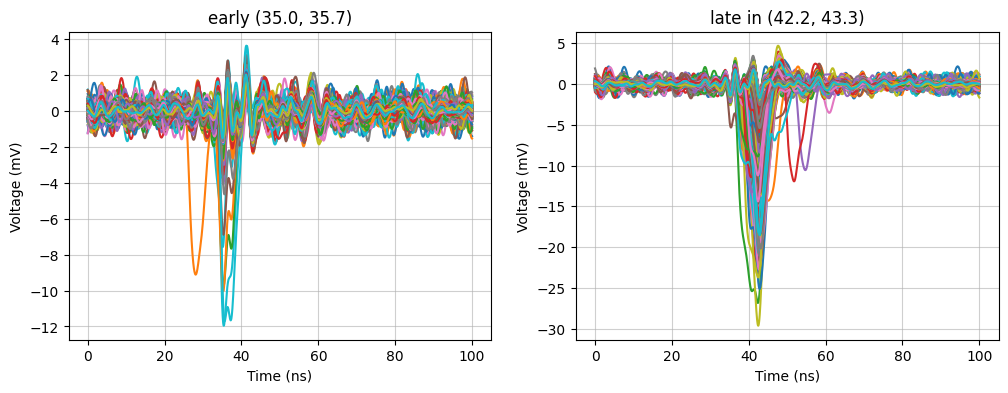

In [15]:


evts=(0, 2000)
fig, axes = plt.subplots(1,2, figsize=(12,4))
add_plot_waveforms(axes[0], time_ns, waveforms_sel[early_mask.values][evts[0]:evts[1]], title=f"early {early_peak}")
add_plot_waveforms(axes[1], time_ns, waveforms_sel[late_mask.values][evts[0]:evts[1]], title=f"late in {late_peak}")


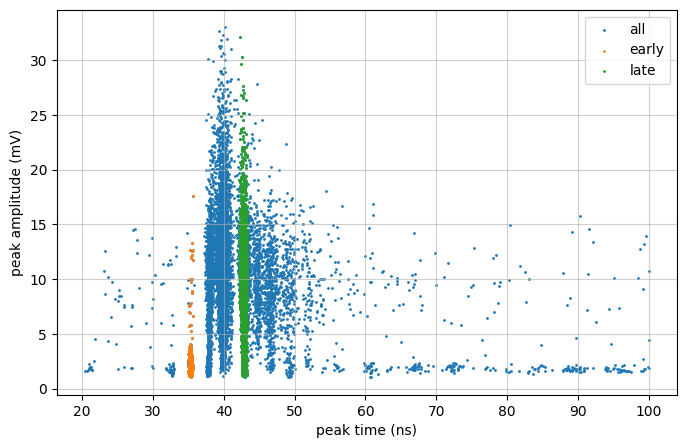

In [16]:
plt.scatter( df_sel["peak_time_ns"],   df_sel["peak_amplitude_mV"], s=1, label='all' );
plt.scatter( df_early["peak_time_ns"], df_early["peak_amplitude_mV"], s=1, label='early' );
plt.scatter( df_late["peak_time_ns"],  df_late["peak_amplitude_mV"], s=1, label='late' );
plt.xlabel('peak time (ns)')
plt.ylabel('peak amplitude (mV)')
plt.legend();


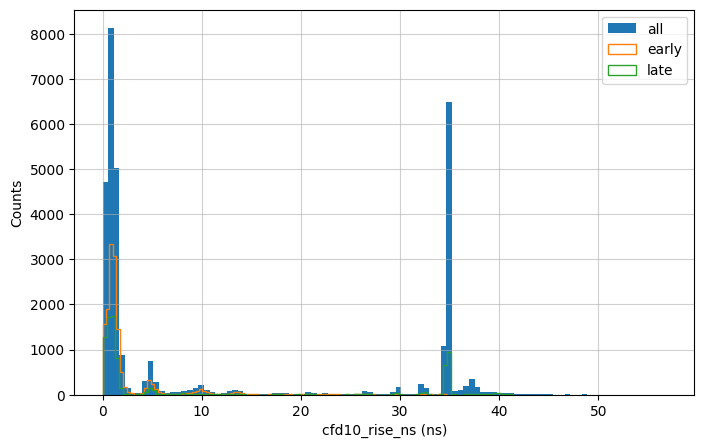

In [17]:
plt.hist(df_sel["cfd10_rise_ns"], bins=100, label='all' );
plt.hist(df_early["cfd10_rise_ns"], bins=100, label='early', histtype='step' );
plt.hist(df_late["cfd10_rise_ns"], bins=100, label='late', histtype='step' );
plt.xlabel('cfd10_rise_ns (ns)');
plt.ylabel('Counts')
plt.legend();


In [18]:
np.mean(np.diff(time_ns)) # sampling period


np.float64(0.015625000000000003)

In [19]:
print(early_mask.mean(), late_mask.mean())

0.4508383422967415 0.263619107877254


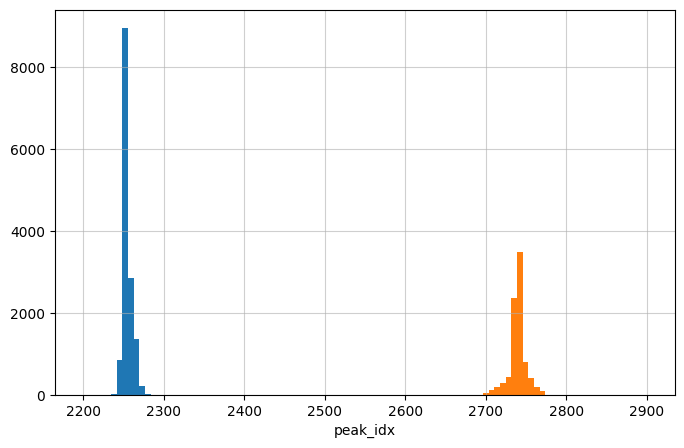

In [20]:
rg = (2200, 2900) #(2200, 2900) #(2500, 3750) #(2500, 3750)
plt.hist(df_early.peak_idx, bins=100, range=rg, label='early');
plt.hist(df_late.peak_idx, bins=100, range=rg, label='late');
plt.xlabel('peak_idx');

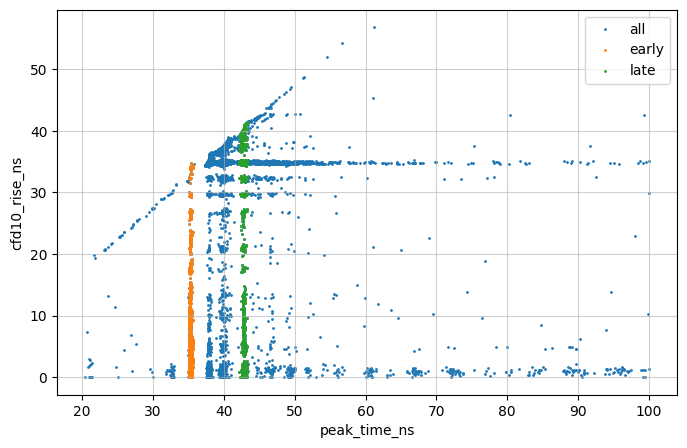

In [21]:
plt.scatter( df_sel["peak_time_ns"],   df_sel["cfd10_rise_ns"], s=1, label='all'  )
plt.scatter( df_early["peak_time_ns"], df_early["cfd10_rise_ns"], s=1, label='early' );
plt.scatter( df_late["peak_time_ns"],  df_late["cfd10_rise_ns"], s=1, label='late' );
plt.xlabel('peak_time_ns')
plt.ylabel('cfd10_rise_ns');
plt.legend();


In [22]:
dt = np.mean(np.diff(time_ns))
print(dt)
print(550 * dt)

0.015625000000000003
8.593750000000002


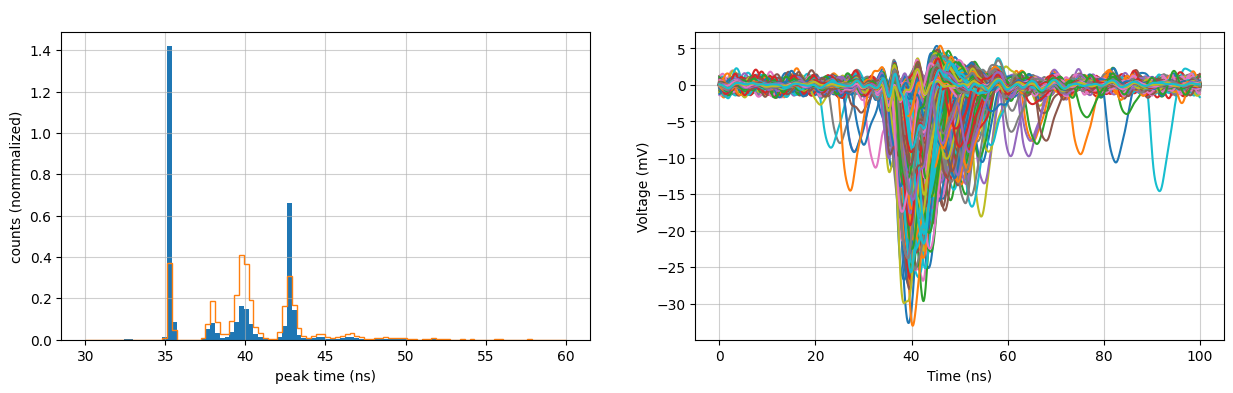

In [23]:
#---- cuts
# mask = df_sel.snr > 10
mask = df_sel.peak_amplitude_mV > 2.0

fig, axes = plt.subplots(1,2, figsize=(15,4))

rg = time_peak_range
den=True
axes[0].hist(df_sel["peak_time_ns"], bins=100, range=rg, density=den);
axes[0].hist(df_sel.loc[mask, "peak_time_ns"], bins=100, range=rg, histtype='step', density=den);
axes[0].set_xlabel('peak time (ns)')
axes[0].set_ylabel('counts (nomrmalized)');

evts=(0, 2000)
add_plot_waveforms(axes[1], time_ns, waveforms_sel[mask][evts[0]:evts[1]], title=f"selection")

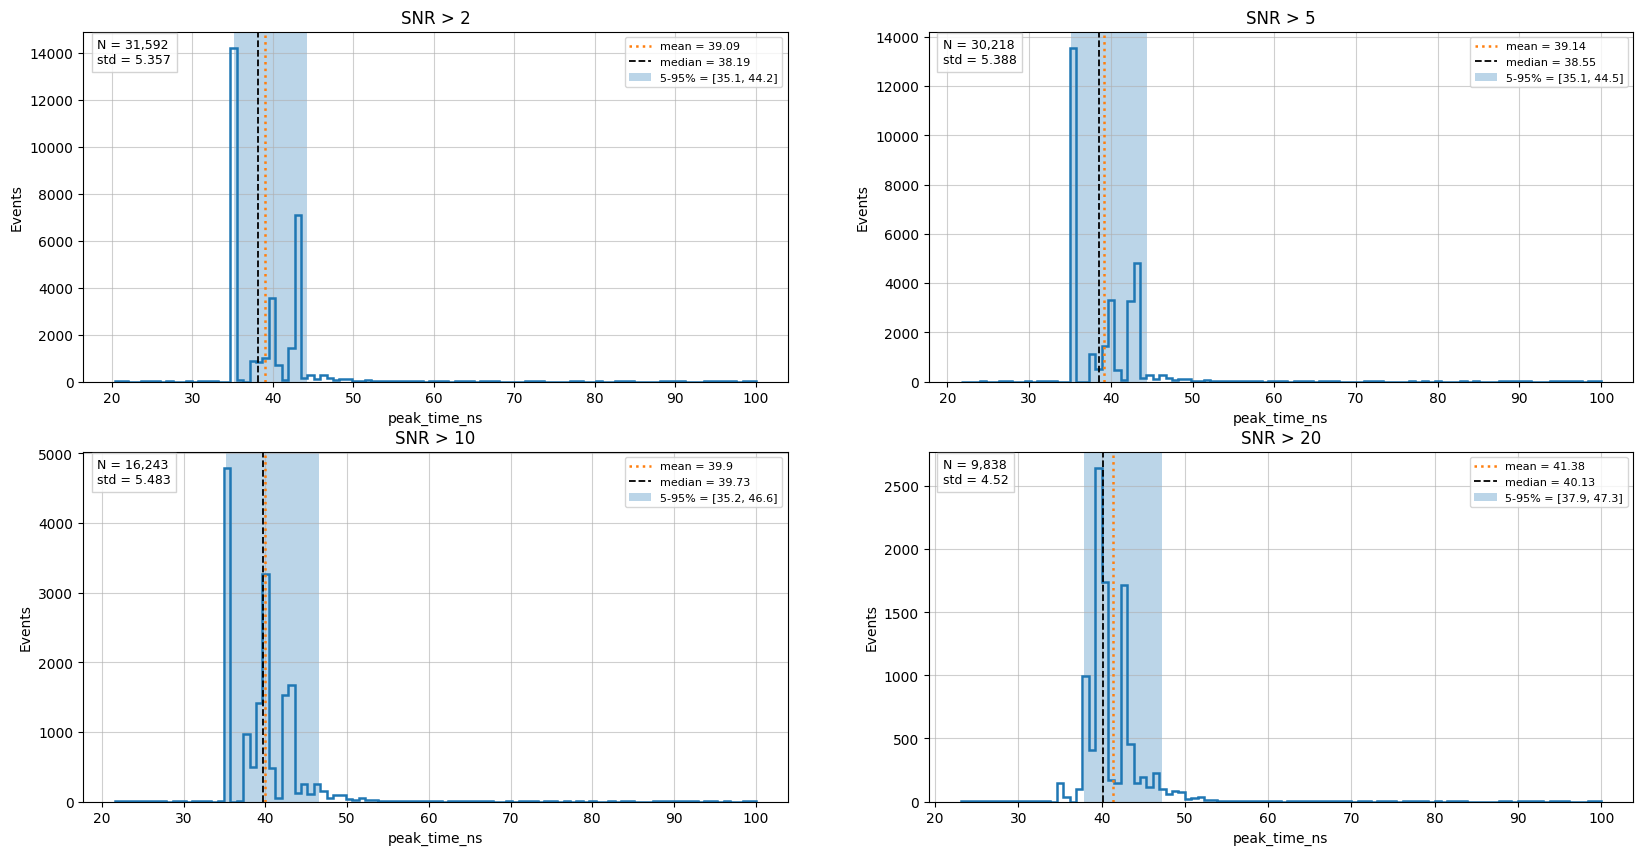

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.ravel()

snr_cuts = [2, 5, 10, 20]
for i in range(0, len(snr_cuts)):
    add_hist_stats(axes[i], df_sel.loc[df_sel.snr > snr_cuts[i], "peak_time_ns"], 100, None, 'peak_time_ns', f'SNR > {snr_cuts[i]}', unit="", show_stat=True, text_position=(0.02, 0.98), legend_loc="best")


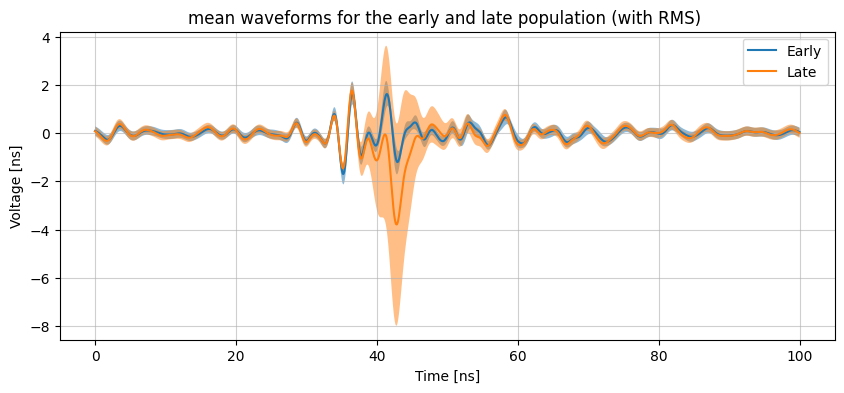

In [25]:
early = df_sel["peak_time_ns"].between(35.2, 35.8)
late  = df_sel["peak_time_ns"].between(43.5, 44.1)

fig, ax = plt.subplots(figsize=(10,4))

add_mean_waveform(
    ax,
    time_ns,
    waveforms_sel[early_mask.values],
    label="Early",
)

add_mean_waveform(
    ax,
    time_ns,
    waveforms_sel[late_mask.values],
    label="Late",
)
ax.set_xlabel('Time [ns]')
ax.set_ylabel('Voltage [ns]')
ax.set_title('mean waveforms for the early and late population (with RMS) ')

ax.legend()

# Trigger

In [26]:
trig_sample = read_waveform_sample(trig_file, max_events=1000, channel=trig_channel, time_origin=time_origin )

ttime_ns = trig_sample["time_ns"]
tvoltage_mV = trig_sample["voltage_mV"]

trig_sample.keys()

dict_keys(['time_ns', 'voltage_mV', 'metadata', 'sample_segments', 'adc_step_mV', 'units_time', 'units_voltage'])

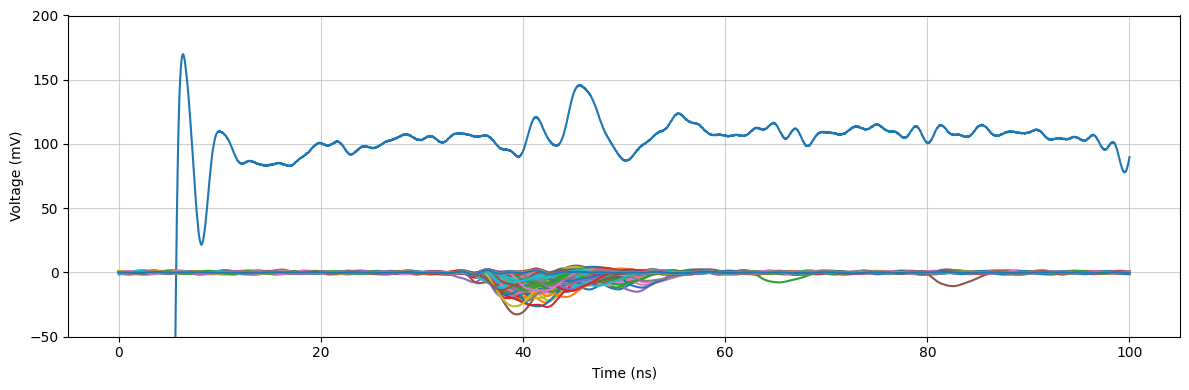

In [27]:
n_to_plot = 1000
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes, ttime_ns, tvoltage_mV[:1]-3000, title=f"")
add_plot_waveforms(axes, time_ns, voltage_mV[:n_to_plot], title=f"")
axes.set_ylim(-50, 200)

fig.tight_layout()

# Compare different samples

In [28]:
from scipy.signal import find_peaks

def load_file_one_go(files, chunk_size, baseline_window_ns, channel):
    prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    subtract_baseline=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None, 
    high_limit_mV=None, 
    margin_mV=0.0,
    max_saturated_samples=0,
    channel=channel,
    time_origin='zero',
    )
    time_ns = prerocessed_data["time_ns"]
    voltage_mV = prerocessed_data["voltage_mV"]

    preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in ['is_saturated', 'n_saturated_samples']}
    preprocessed_event_info.update({ 
        'event_file': prerocessed_data['event_file'],
        'event_segment': prerocessed_data['event_segment']
    })

    df = build_waveform_feature_dataframe(
        time_ns,
        voltage_mV,
        peak_threshold_mV=None,
        second_peak_min_height_frac=0.2,
        pre_peak_ns = 20,
        post_peak_ns = 80,
        pre_rise_ns = 10, 
        post_rise_ns = 80, 
        extra=preprocessed_event_info 
    )
    cutflow = CutFlow(len(df))

    cutflow.apply( "peaks in the baseline", reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 ) )
    cutflow.print()

    df_sel = df[cutflow.mask].copy()
    waveforms_sel = voltage_mV[cutflow.mask]

    return time_ns, waveforms_sel, df_sel


In [ ]:
## ch2 - 20MHz
files_ch1, channel_ch1 = ["data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-1.h5",
                          "data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-2.h5"], "Channel 1"
## ch2 - 525MHz
files_ch2, channel_ch2 = ["data/WA0089/LED_sweep/260625/850V_525MHz/led_100-10.h5"], "Channel 2"
## ch4 - 525MHz
files_ch4, channel_ch4 = [ "data/LED_Trigger/260629/tri_seg_ch4_Pmt.h5"], "Channel 4"

t_ch4, V_ch4, df_ch4 = load_file_one_go(files_ch4, 512, baseline_window_ns, channel_ch4)
t_ch2, V_ch2, df_ch2 = load_file_one_go(files_ch2, 512, baseline_window_ns, channel_ch2)
t_ch1, V_ch1, df_ch1 = load_file_one_go(files_ch1, 512, baseline_window_ns, channel_ch1)

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31673      100.0%        100.0%
peaks in the baseline         31610       99.8%         99.8%


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31000      100.0%        100.0%
peaks in the baseline         30984       99.9%         99.9%


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       63353      100.0%        100.0%
peaks in the baseline         63348      100.0%        100.0%


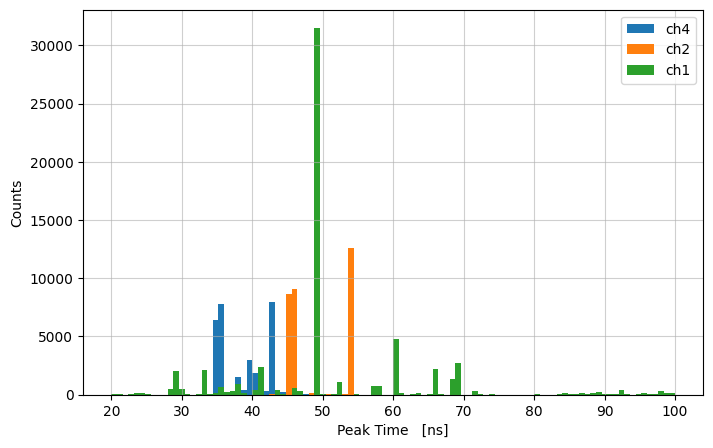

In [31]:
rg = (20, 100) 
var = "peak_time_ns"
plt.hist(df_ch4[var], bins=100, range=rg, label='ch4');
plt.hist(df_ch2[var], bins=100, range=rg, label='ch2');
plt.hist(df_ch1[var], bins=100, range=rg, label='ch1');

plt.legend(loc='upper right')
plt.xlabel("Peak Time   [ns]")
plt.ylabel("Counts");


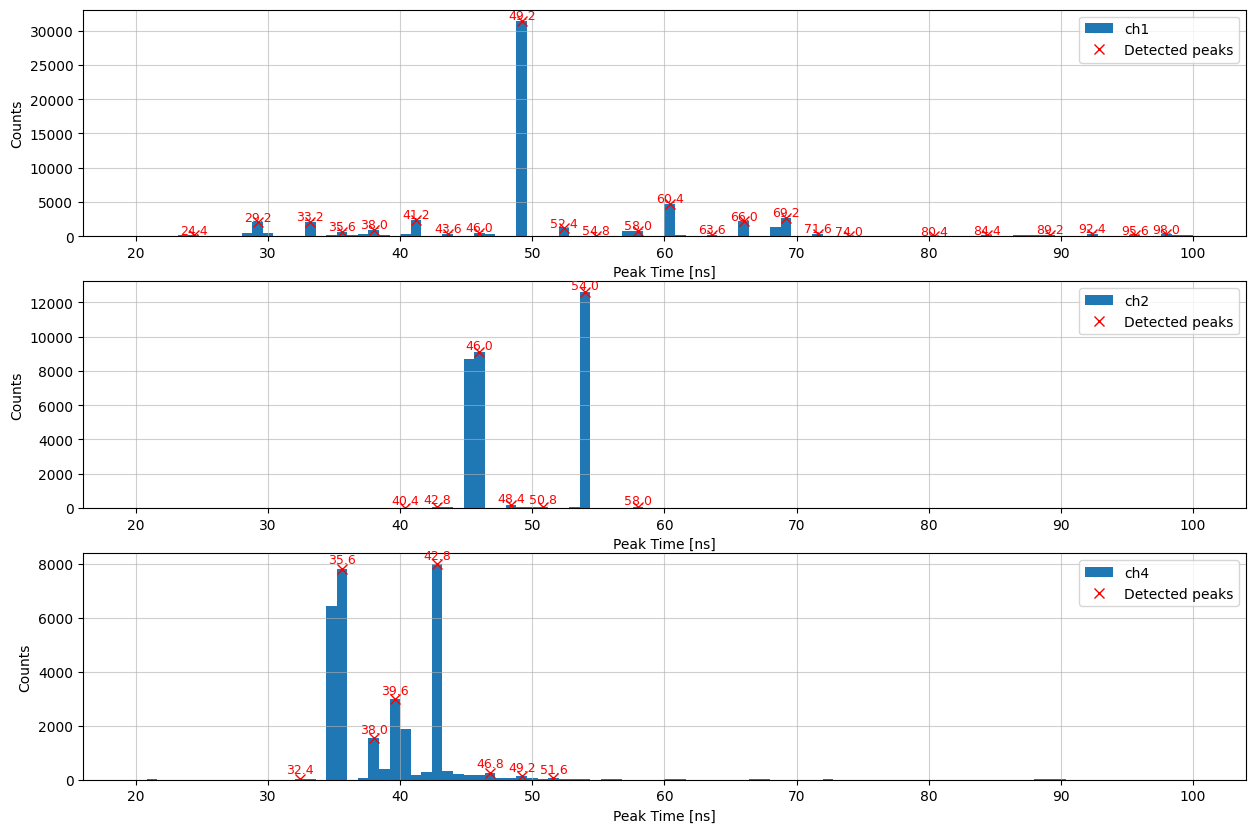

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
axes = axes.ravel()

rg = (20, 100)

dfs = [df_ch1, df_ch2, df_ch4]
chs = ['ch1', 'ch2', 'ch4']
time_differences=[]
for i in range(0, len(dfs)):
    counts, edges, _ = axes[i].hist(dfs[i]["peak_time_ns"], bins=100, range=rg, label=chs[i]);
    centers = 0.5 * (edges[:-1] + edges[1:])

    peak_idx, properties = find_peaks(
        counts,
        prominence=20,    # adjust as needed
        distance=2,        # minimum number of bins between peaks
    )
    axes[i].plot( centers[peak_idx], counts[peak_idx], "rx", ms=7, mew=1, label="Detected peaks" )
    for x, y in zip(centers[peak_idx], counts[peak_idx]):
        axes[i].text( x, y + 200, f"{x:.1f}", ha="center", color="red", fontsize=9, )

    axes[i].legend(loc="upper right")
    axes[i].set_xlabel("Peak Time [ns]")
    axes[i].set_ylabel("Counts");
    
    peak_times = centers[peak_idx]
    time_differences.append(np.diff(peak_times))


In [33]:
for dt in time_differences:
    print(f"{np.min(dt):.1f}, {np.max(dt):.1f}")

2.4, 6.4
2.4, 4.0
1.6, 4.0


In [34]:
time_differences[2]

array([3.2, 2.4, 1.6, 3.2, 4. , 2.4, 2.4])

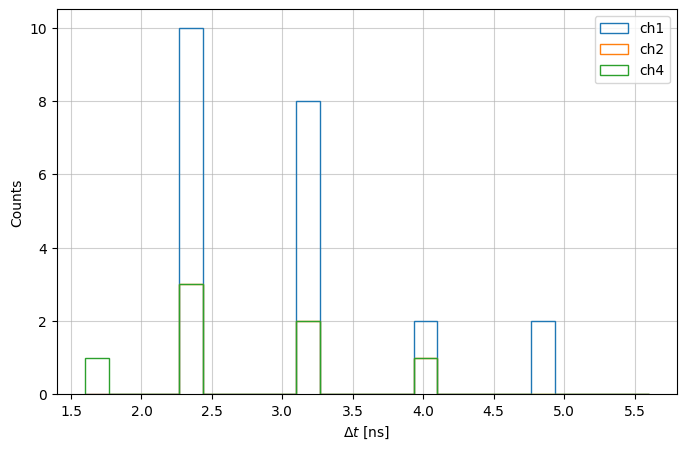

In [35]:
bins = np.linspace(1.6, 5.6, 25)

for i in range(0, len(time_differences)):
    plt.hist(time_differences[i], bins = bins, label=chs[i], histtype='step', range=rg);
    plt.xlabel(r"$\Delta t$ [ns]")
    plt.ylabel("Counts");
    plt.legend();



# Focus on ch1

In [36]:
## ch1 - 20MHz
files, channel = [f"data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-{i}.h5" for i in range(1,11)], "Channel 1"

t_ch1, V_ch1, df_ch1 = load_file_one_go(files, 512, baseline_window_ns, channel)

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                      316767      100.0%        100.0%
peaks in the baseline        316737      100.0%        100.0%


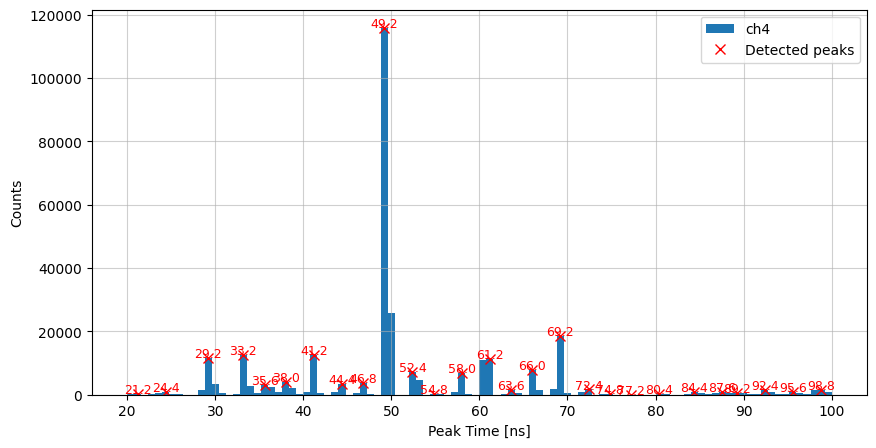

In [37]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

rg = (20, 100)

counts, edges, _ = axes.hist(df_ch1["peak_time_ns"], bins=100, range=rg, label=chs[i]);
centers = 0.5 * (edges[:-1] + edges[1:])

peak_idx, properties = find_peaks(
    counts,
    prominence=20,    # adjust as needed
    distance=2,        # minimum number of bins between peaks
)
axes.plot( centers[peak_idx], counts[peak_idx], "rx", ms=7, mew=1, label="Detected peaks" )
for x, y in zip(centers[peak_idx], counts[peak_idx]):
    axes.text( x, y + 200, f"{x:.1f}", ha="center", color="red", fontsize=9, )

axes.legend(loc="upper right")
axes.set_xlabel("Peak Time [ns]")
axes.set_ylabel("Counts");

peak_times = centers[peak_idx]
time_differences = np.diff(peak_times)

In [38]:
time_differences

array([3.2, 4.8, 4. , 2.4, 2.4, 3.2, 3.2, 2.4, 2.4, 3.2, 2.4, 3.2, 3.2,
       2.4, 2.4, 3.2, 3.2, 2.4, 2.4, 3.2, 4. , 3.2, 1.6, 3.2, 3.2, 3.2])

In [39]:
np.min(time_differences), np.max(time_differences)

(np.float64(1.6000000000000085), np.float64(4.800000000000004))

In [40]:
time_differences

array([3.2, 4.8, 4. , 2.4, 2.4, 3.2, 3.2, 2.4, 2.4, 3.2, 2.4, 3.2, 3.2,
       2.4, 2.4, 3.2, 3.2, 2.4, 2.4, 3.2, 4. , 3.2, 1.6, 3.2, 3.2, 3.2])

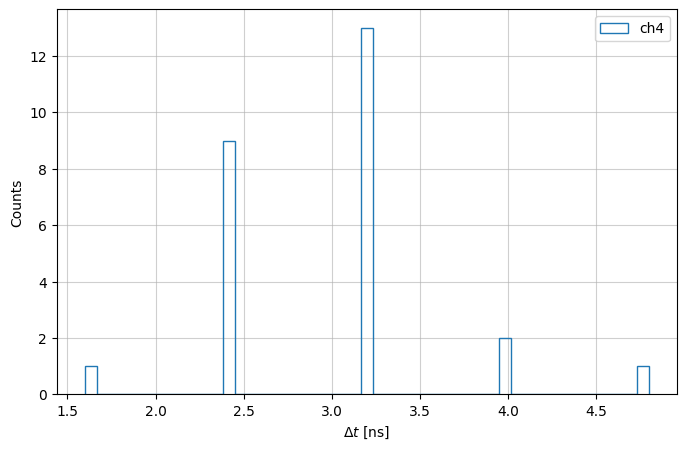

In [41]:
bins = np.linspace(np.min(time_differences), np.max(time_differences), 50)

# for i in range(0, len(time_differences)):
plt.hist(time_differences,  bins = bins, label=chs[i], histtype='step', range=None);
plt.xlabel(r"$\Delta t$ [ns]")
plt.ylabel("Counts");
plt.legend();

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31584      100.0%        100.0%
peaks in the baseline         31580      100.0%        100.0%


(np.float64(2.3999999999999986), np.float64(13.599999999999994))

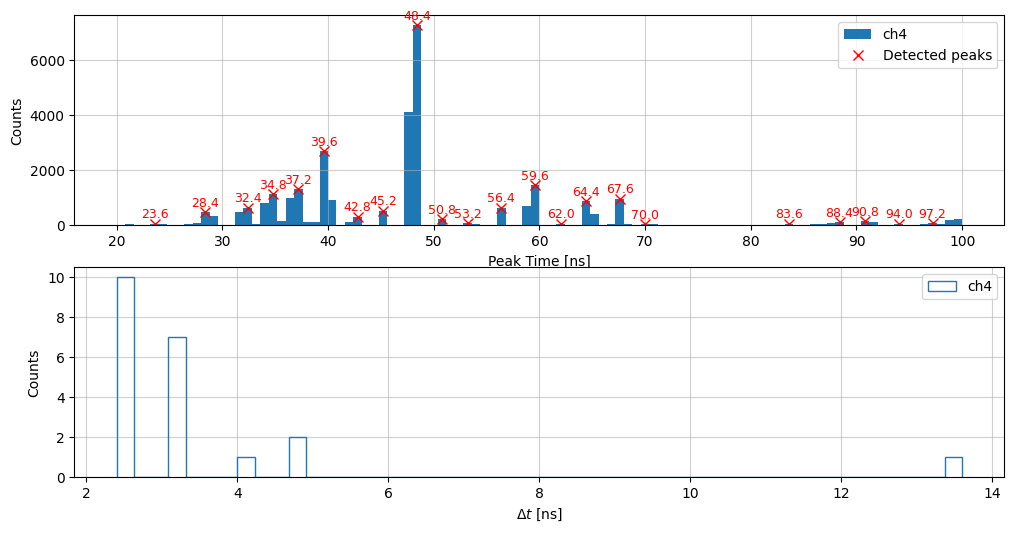

In [42]:
## ch1 - 20MHz
files, channel = [f"data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led2-{i}.h5" for i in range(1,2)], "Channel 1"
t_ch1, V_ch1, df_ch1 = load_file_one_go(files, 512, baseline_window_ns, channel)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes = axes.ravel()

rg = (20, 100)

counts, edges, _ = axes[0].hist(df_ch1["peak_time_ns"], bins=100, range=rg, label=chs[i]);
centers = 0.5 * (edges[:-1] + edges[1:])

peak_idx, properties = find_peaks(
    counts,
    prominence=20,    # adjust as needed
    distance=2,        # minimum number of bins between peaks
)
axes[0].plot( centers[peak_idx], counts[peak_idx], "rx", ms=7, mew=1, label="Detected peaks" )
for x, y in zip(centers[peak_idx], counts[peak_idx]):
    axes[0].text( x, y + 200, f"{x:.1f}", ha="center", color="red", fontsize=9, )

axes[0].legend(loc="upper right")
axes[0].set_xlabel("Peak Time [ns]")
axes[0].set_ylabel("Counts");

peak_times = centers[peak_idx]
time_differences = np.diff(peak_times)

bins = np.linspace(np.min(time_differences), np.max(time_differences), 50)
axes[1].hist(time_differences,   bins = bins, label=chs[i], histtype='step', range=None);
axes[1].set_xlabel(r"$\Delta t$ [ns]")
axes[1].set_ylabel("Counts");
axes[1].legend();

np.min(time_differences), np.max(time_differences)

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31681      100.0%        100.0%
peaks in the baseline         31678      100.0%        100.0%


(np.float64(1.6000000000000014), np.float64(16.0))

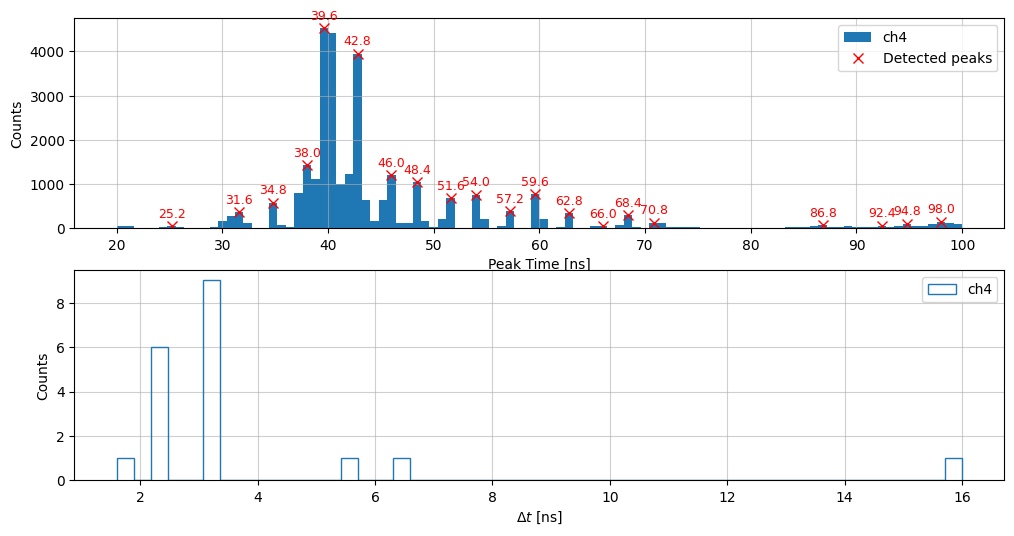

In [43]:
## ch1 - 20MHz
files, channel = [f"data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led3-{i}.h5" for i in range(1,2)], "Channel 1"
t_ch1, V_ch1, df_ch1 = load_file_one_go(files, 512, baseline_window_ns, channel)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes = axes.ravel()

rg = (20, 100)

counts, edges, _ = axes[0].hist(df_ch1["peak_time_ns"], bins=100, range=rg, label=chs[i]);
centers = 0.5 * (edges[:-1] + edges[1:])

peak_idx, properties = find_peaks(
    counts,
    prominence=20,    # adjust as needed
    distance=2,        # minimum number of bins between peaks
)
axes[0].plot( centers[peak_idx], counts[peak_idx], "rx", ms=7, mew=1, label="Detected peaks" )
for x, y in zip(centers[peak_idx], counts[peak_idx]):
    axes[0].text( x, y + 200, f"{x:.1f}", ha="center", color="red", fontsize=9, )

axes[0].legend(loc="upper right")
axes[0].set_xlabel("Peak Time [ns]")
axes[0].set_ylabel("Counts");

peak_times = centers[peak_idx]
time_differences = np.diff(peak_times)

bins = np.linspace(np.min(time_differences), np.max(time_differences), 50)
axes[1].hist(time_differences,   bins = bins, label=chs[i], histtype='step', range=None);
axes[1].set_xlabel(r"$\Delta t$ [ns]")
axes[1].set_ylabel("Counts");
axes[1].legend();

np.min(time_differences), np.max(time_differences)

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31679      100.0%        100.0%
peaks in the baseline         31679      100.0%        100.0%


(np.float64(2.3999999999999986), np.float64(5.6000000000000085))

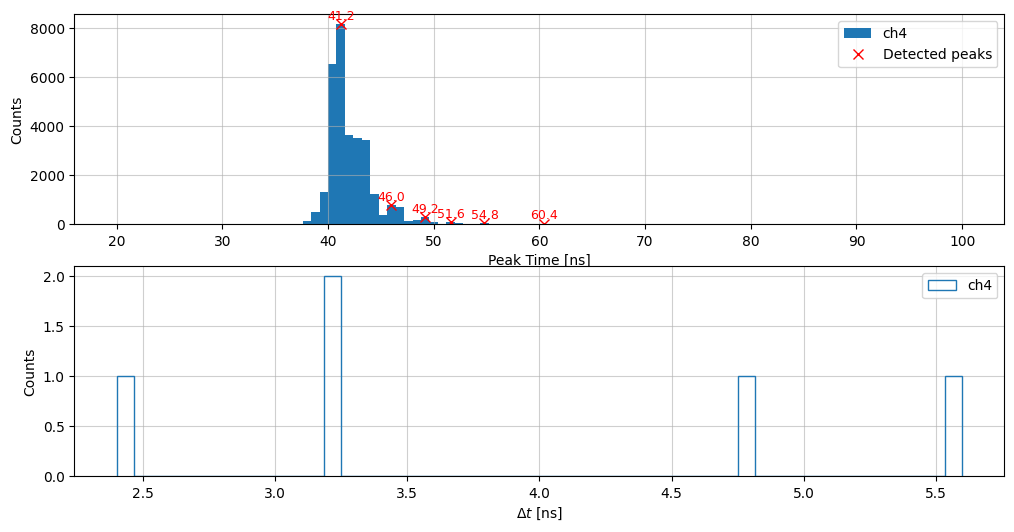

In [44]:
## ch1 - 20MHz
files, channel = [f"data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led4-{i}.h5" for i in range(1,2)], "Channel 1"
t_ch1, V_ch1, df_ch1 = load_file_one_go(files, 512, baseline_window_ns, channel)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes = axes.ravel()

rg = (20, 100)

counts, edges, _ = axes[0].hist(df_ch1["peak_time_ns"], bins=100, range=rg, label=chs[i]);
centers = 0.5 * (edges[:-1] + edges[1:])

peak_idx, properties = find_peaks(
    counts,
    prominence=20,    # adjust as needed
    distance=2,        # minimum number of bins between peaks
)
axes[0].plot( centers[peak_idx], counts[peak_idx], "rx", ms=7, mew=1, label="Detected peaks" )
for x, y in zip(centers[peak_idx], counts[peak_idx]):
    axes[0].text( x, y + 200, f"{x:.1f}", ha="center", color="red", fontsize=9, )

axes[0].legend(loc="upper right")
axes[0].set_xlabel("Peak Time [ns]")
axes[0].set_ylabel("Counts");

peak_times = centers[peak_idx]
time_differences = np.diff(peak_times)

bins = np.linspace(np.min(time_differences), np.max(time_differences), 50)
axes[1].hist(time_differences,   bins = bins, label=chs[i], histtype='step', range=None);
axes[1].set_xlabel(r"$\Delta t$ [ns]")
axes[1].set_ylabel("Counts");
axes[1].legend();

np.min(time_differences), np.max(time_differences)

# Maybe the answer is here

In [175]:
def get_period_peak_to_peak(t_ns, waveforms, t_range, mask_events, verbose=True, prominence=None, distance=None):
    mask_time = (t_ns > t_range[0]) & (t_ns < t_range[1])
    t_window = t_ns[mask_time]
    mean_waveform = np.mean( waveforms[mask_events.values], axis=0 )
    v_window = mean_waveform[mask_time]

    peaks, _ = find_peaks(v_window, prominence=prominence, distance=distance)

    peak_times = t_window[peaks]
    periods = np.diff(peak_times)

    if verbose:
        print(f"Time window  : {t_window[0]:.3f} to {t_window[-1]:.3f} ns")
        print(f"N peaks      : {len(peaks)}")
        print(f"Mean period = {periods.mean():.3f} ns")
        print(f"Frequency   = {1/periods.mean():.3f} GHz")

    return periods.mean(), 1/periods.mean(), peak_times

In [125]:
## ch1 - 20MHz
files_ch1, channel_ch1 = ["data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-1.h5"], "Channel 1"
## ch2 - 525MHz
files_ch2, channel_ch2 = ["data/WA0089/LED_sweep/260625/850V_525MHz/led_100-10.h5"], "Channel 2"
## ch4 - 525MHz
files_ch4, channel_ch4 = [ "data/LED_Trigger/260629/tri_seg_ch4_Pmt.h5"], "Channel 4"

t_ch4, V_ch4, df_ch4 = load_file_one_go(files_ch4, 512, baseline_window_ns, channel_ch4)
t_ch2, V_ch2, df_ch2 = load_file_one_go(files_ch2, 512, baseline_window_ns, channel_ch2)
t_ch1, V_ch1, df_ch1 = load_file_one_go(files_ch1, 512, baseline_window_ns, channel_ch1)

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31673      100.0%        100.0%
peaks in the baseline         31610       99.8%         99.8%


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31000      100.0%        100.0%
peaks in the baseline         30984       99.9%         99.9%


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31677      100.0%        100.0%
peaks in the baseline         31673      100.0%        100.0%


Time window  : 35.062 to 64.938 ns
N peaks      : 11
Mean period = 2.794 ns
Frequency   = 0.358 GHz


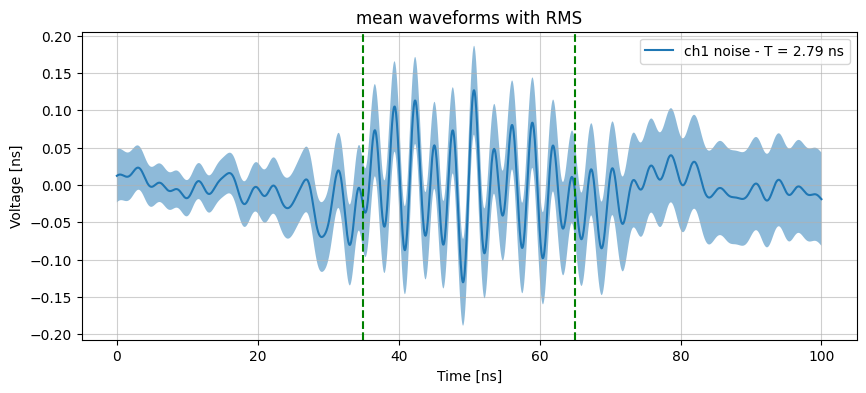

In [205]:
mask_pulse_ch1 = df_ch1.peak_amplitude_mV > 1
mask_noise_ch1 = ~mask_pulse_ch1

fig, ax = plt.subplots(figsize=(10,4))


w = (35, 65)
T_ch1, f_ch1, peaks_ch1 = get_period_peak_to_peak(t_ch1, V_ch1, w, mask_noise_ch1)
# add_mean_waveform( ax, t_ch1, V_ch1[mask_pulse_ch1.values], label="ch1 pulses" )
add_mean_waveform( ax, t_ch1, V_ch1[mask_noise_ch1.values], label=f"ch1 noise - T = {T_ch1:.2f} ns" )
ax.axvline(w[0], color='green', linestyle='dashed')
ax.axvline(w[1], color='green', linestyle='dashed')

# ax.vlines(peaks_ch1, ymin=0, ymax=0.15, color='red', linestyles='dashed')

ax.set_xlabel('Time [ns]')
ax.set_ylabel('Voltage [ns]')
ax.set_title('mean waveforms with RMS')

ax.legend();

Time window  : 35.016 to 64.984 ns
N peaks      : 9
Mean period = 2.891 ns
Frequency   = 0.346 GHz


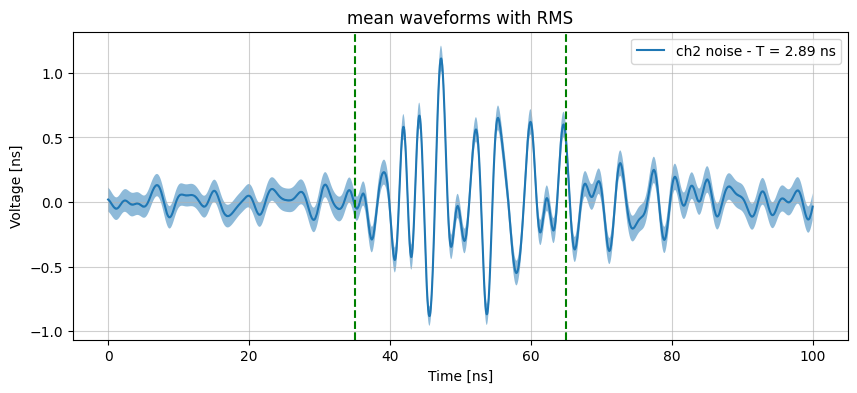

In [206]:
mask_pulse_ch2 = df_ch2.peak_amplitude_mV > 1
mask_noise_ch2 = ~mask_pulse_ch2

fig, ax = plt.subplots(figsize=(10,4))


w = (35, 65)
T_ch2, f_ch2, peaks_ch2 = get_period_peak_to_peak(t_ch2, V_ch2, w, mask_noise_ch2,  prominence=0.2, distance=None)
# add_mean_waveform( ax, t_ch2, V_ch2[mask_pulse_ch2.values], label="ch2 pulses" )
add_mean_waveform( ax, t_ch2, V_ch2[mask_noise_ch2.values], label=f"ch2 noise - T = {T_ch2:.2f} ns" )
ax.axvline(w[0], color='green', linestyle='dashed')
ax.axvline(w[1], color='green', linestyle='dashed')
# ax.vlines(peaks_ch2, ymin=0, ymax=0.5, color='red', linestyles='dashed')

ax.set_xlabel('Time [ns]')
ax.set_ylabel('Voltage [ns]')
ax.set_title('mean waveforms with RMS')

ax.legend();

Time window  : 35.016 to 57.984 ns
N peaks      : 7
Mean period = 2.766 ns
Frequency   = 0.362 GHz


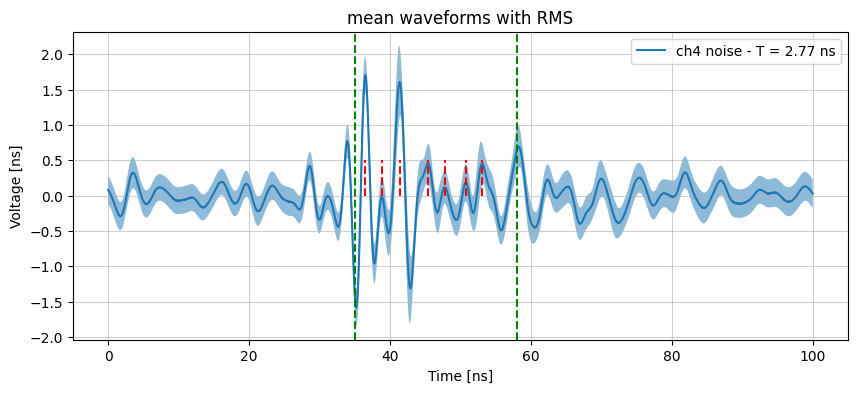

In [207]:
mask_pulse_ch4 = df_ch4.peak_amplitude_mV > 3
mask_noise_ch4 = ~mask_pulse_ch4

fig, ax = plt.subplots(figsize=(10,4))


w = (35, 58)
T_ch4, f_ch4, peaks_ch4 = get_period_peak_to_peak(t_ch4, V_ch4, w, mask_noise_ch4,  prominence=0.2, distance=None)
# add_mean_waveform( ax, t_ch4, V_ch4[mask_pulse_ch4.values], label="ch4 pulses" )
add_mean_waveform( ax, t_ch4, V_ch4[mask_noise_ch4.values], label=f"ch4 noise - T = {T_ch4:.2f} ns" )
ax.axvline(w[0], color='green', linestyle='dashed')
ax.axvline(w[1], color='green', linestyle='dashed')
ax.vlines(peaks_ch4, ymin=0, ymax=0.5, color='red', linestyles='dashed')

ax.set_xlabel('Time [ns]')
ax.set_ylabel('Voltage [ns]')
ax.set_title('mean waveforms with RMS')

ax.legend();

In [ ]:
sprint(f'period ch1: {T_ch1:.2f} ns')
print(f'period ch2: {T_ch2:.2f} ns')
print(f'period ch4: {T_ch4:.2f} ns')

period ch1: 2.79 ns
period ch2: 2.89 ns
period ch4: 2.77 ns


In [212]:

4*0.8

3.2

Mean period = 2.794 ns
Frequency   = 0.358 GHz

Mean period = 2.258 ns
Frequency   = 0.443 GHz

Mean period = 0.581 ns
Frequency   = 1.721 GHz



In [ ]:
mask = (t_ch2 > 35) & (t_ch1 < 65)

t = t_ch1[mask]
mean_waveform = np.mean( V_ch1[mask_noise_ch1.values], axis=0 )
v = mean_waveform[mask]

peaks, _ = find_peaks(v)
periods = np.diff(t[peaks])
print(f"Mean period = {periods.mean():.3f} ns")
print(f"Frequency   = {1/periods.mean():.3f} GHz")

IndexError: index 1966 is out of bounds for axis 0 with size 1919

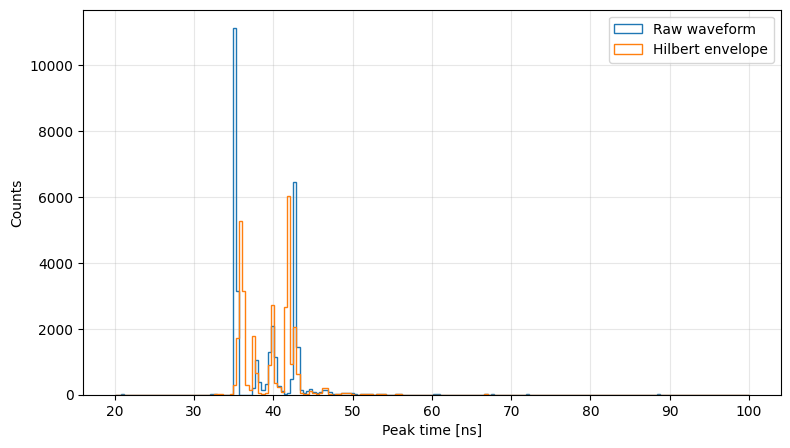

In [110]:
from scipy.signal import hilbert

#
# Compute the analytic signal and its envelope
#

analytic_signal = hilbert( waveforms_sel, axis=1 ) 
envelope = np.abs( analytic_signal )

#
# Timing from the envelope
#

peak_idx_env = np.argmax( envelope, axis=1 )

peak_time_env_ns = time_ns[ peak_idx_env ]

#
# Timing from the raw waveform
#

peak_idx_raw = np.argmax( -waveforms_sel, axis=1 ) # assuming negative PMT pulses
peak_time_raw_ns = time_ns[ peak_idx_raw ]

#
# Plot
#

fig, ax = plt.subplots(figsize=(9,5))

bins = np.linspace( 20, 100, 200 )

ax.hist( peak_time_raw_ns, bins=bins, histtype="step", lw=1, label="Raw waveform")
ax.hist( peak_time_env_ns, bins=bins, histtype="step", lw=1, label="Hilbert envelope")

ax.set_xlabel("Peak time [ns]")
ax.set_ylabel("Counts")
ax.legend()
ax.grid(alpha=0.3)

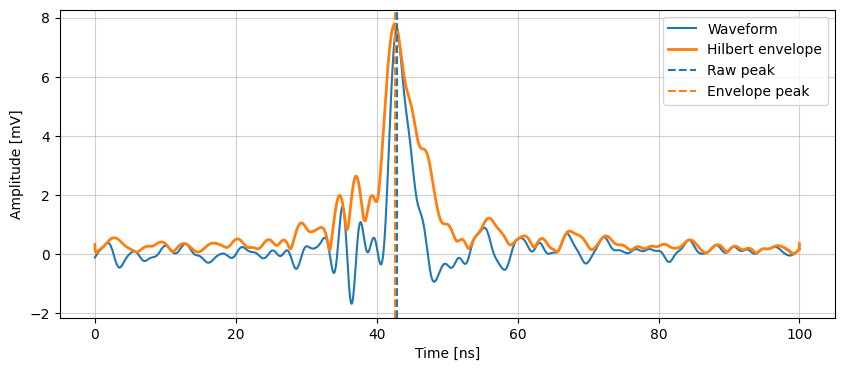

In [111]:
i = 0

fig, ax = plt.subplots(figsize=(10,4))

ax.plot(
    time_ns,
    -waveforms_sel[i],
    label="Waveform",
)

ax.plot(
    time_ns,
    envelope[i],
    lw=2,
    label="Hilbert envelope",
)

ax.axvline(
    peak_time_raw_ns[i],
    color="C0",
    ls="--",
    label="Raw peak",
)

ax.axvline(
    peak_time_env_ns[i],
    color="C1",
    ls="--",
    label="Envelope peak",
)

ax.set_xlabel("Time [ns]")
ax.set_ylabel("Amplitude [mV]")
ax.legend()